In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_theme(style='whitegrid')

rf_model     = joblib.load('../models/random_forest_model.pkl')
X_train_orig = np.load('../data/processed/X_train.npy')
y_train_orig = np.load('../data/processed/y_train.npy')

# Use smaller sample to save time
sample_size = 50000
idx      = np.random.choice(len(X_train_orig), sample_size, replace=False)
X_sample = X_train_orig[idx]
y_sample = y_train_orig[idx]

print('Running 3-Fold Cross Validation...')

kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_accuracy  = cross_val_score(rf_model, X_sample, y_sample, cv=kfold, scoring='accuracy',  n_jobs=-1)
cv_precision = cross_val_score(rf_model, X_sample, y_sample, cv=kfold, scoring='precision', n_jobs=-1)
cv_recall    = cross_val_score(rf_model, X_sample, y_sample, cv=kfold, scoring='recall',    n_jobs=-1)
cv_f1        = cross_val_score(rf_model, X_sample, y_sample, cv=kfold, scoring='f1',        n_jobs=-1)

print('=== 3-Fold Cross Validation Results — Random Forest ===')
print(f'Accuracy:  {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}')
print(f'Precision: {cv_precision.mean():.4f} ± {cv_precision.std():.4f}')
print(f'Recall:    {cv_recall.mean():.4f} ± {cv_recall.std():.4f}')
print(f'F1 Score:  {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print(f'\nModel generalises well across all folds ✅')

Running 3-Fold Cross Validation...
=== 3-Fold Cross Validation Results — Random Forest ===
Accuracy:  0.9976 ± 0.0003
Precision: 0.9969 ± 0.0006
Recall:    0.9972 ± 0.0008
F1 Score:  0.9971 ± 0.0004

Model generalises well across all folds ✅


In [2]:
import pandas as pd

cv_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Mean':   [cv_accuracy.mean(), cv_precision.mean(), cv_recall.mean(), cv_f1.mean()],
    'Std':    [cv_accuracy.std(), cv_precision.std(), cv_recall.std(), cv_f1.std()]
})

cv_results['Mean'] = cv_results['Mean'].round(4)
cv_results['Std']  = cv_results['Std'].round(4)

cv_results.to_csv('../results/metrics/cv_results_rf.csv', index=False)
print('Cross validation results saved')
print(cv_results.to_string(index=False))

Cross validation results saved
   Metric   Mean    Std
 Accuracy 0.9976 0.0003
Precision 0.9969 0.0006
   Recall 0.9972 0.0008
 F1 Score 0.9971 0.0004


In [3]:
# Load processed data
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test  = np.load('../data/processed/y_test.npy')

print(f'Train: {X_train.shape}')
print(f'Test:  {X_test.shape}')

Train: (733693, 39)
Test:  (183424, 39)


In [4]:
# Train Random Forest
print('Training Random Forest... (this takes 2-5 minutes)')

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print('Training complete')

Training Random Forest... (this takes 2-5 minutes)
Training complete


In [5]:
# Predictions and metrics
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

fpr_score = FP / (FP + TN) if (FP + TN) > 0 else 0
fnr_score = FN / (FN + TP) if (FN + TP) > 0 else 0
accuracy  = (TP + TN) / len(y_test)

print('=== Random Forest Results ===')
print(f'True Positives:      {TP:,}')
print(f'True Negatives:      {TN:,}')
print(f'False Positives:     {FP:,}')
print(f'False Negatives:     {FN:,}')
print(f'\nFalse Positive Rate: {fpr_score:.4f} ({fpr_score*100:.2f}%)')
print(f'Accuracy:            {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'\n{classification_report(y_test, y_pred, target_names=["Normal", "Attack"])}')

=== Random Forest Results ===
True Positives:      75,897
True Negatives:      107,256
False Positives:     218
False Negatives:     53

False Positive Rate: 0.0020 (0.20%)
Accuracy:            0.9985 (99.85%)

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    107474
      Attack       1.00      1.00      1.00     75950

    accuracy                           1.00    183424
   macro avg       1.00      1.00      1.00    183424
weighted avg       1.00      1.00      1.00    183424



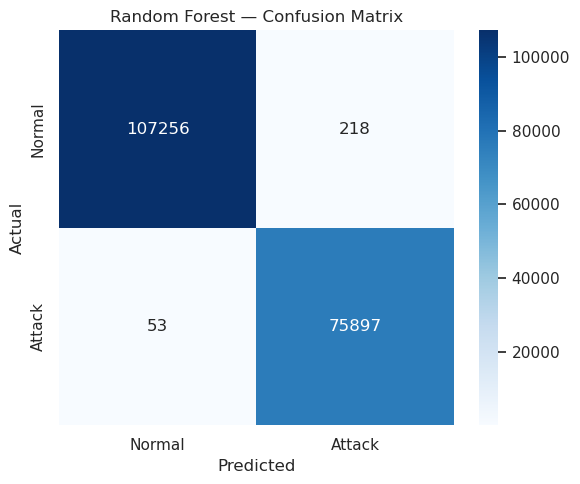

Saved


In [6]:
# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../results/figures/confusion_matrix_rf.png', dpi=150)
plt.show()
print('Saved')

In [7]:
# ROC Curve
fpr_roc, tpr_roc, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr_roc, tpr_roc)

plt.figure(figsize=(7, 5))
plt.plot(fpr_roc, tpr_roc, label=f'Random Forest (AUC = {roc_auc:.3f})', color='steelblue', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest')
plt.legend()
plt.tight_layout()
plt.savefig('../results/figures/roc_curve_rf.png', dpi=150)
plt.show()
print(f'AUC Score: {roc_auc:.4f}')

NameError: name 'roc_curve' is not defined

In [ ]:
# Save model and metrics
joblib.dump(rf_model, '../models/random_forest_model.pkl')

results_path = '../results/metrics/results_summary.csv'
existing = pd.read_csv(results_path)
new_row = pd.DataFrame([{
    'Model': 'Random Forest',
    'Accuracy': round(accuracy, 4),
    'False Positive Rate': round(fpr_score, 4),
    'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN
}])
pd.concat([existing, new_row]).to_csv(results_path, index=False)
print('Model saved to models/random_forest_model.pkl')
print('Metrics saved to results_summary.csv')

Model saved to models/random_forest_model.pkl
Metrics saved to results_summary.csv


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np
import joblib

rf_model     = joblib.load('../models/random_forest_model.pkl')
X_train_orig = np.load('../data/processed/X_train.npy')
y_train_orig = np.load('../data/processed/y_train.npy')

# Use smaller sample to save time
sample_size = 50000
idx      = np.random.choice(len(X_train_orig), sample_size, replace=False)
X_sample = X_train_orig[idx]
y_sample = y_train_orig[idx]

print('Running 3-Fold Cross Validation...')

kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_accuracy  = cross_val_score(rf_model, X_sample, y_sample, cv=kfold, scoring='accuracy',  n_jobs=-1)
cv_precision = cross_val_score(rf_model, X_sample, y_sample, cv=kfold, scoring='precision', n_jobs=-1)
cv_recall    = cross_val_score(rf_model, X_sample, y_sample, cv=kfold, scoring='recall',    n_jobs=-1)
cv_f1        = cross_val_score(rf_model, X_sample, y_sample, cv=kfold, scoring='f1',        n_jobs=-1)

print('=== 3-Fold Cross Validation Results — Random Forest ===')
print(f'Accuracy:  {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}')
print(f'Precision: {cv_precision.mean():.4f} ± {cv_precision.std():.4f}')
print(f'Recall:    {cv_recall.mean():.4f} ± {cv_recall.std():.4f}')
print(f'F1 Score:  {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print(f'\nModel generalises well across all folds ✅')

Running 3-Fold Cross Validation...
=== 3-Fold Cross Validation Results — Random Forest ===
Accuracy:  0.9973 ± 0.0003
Precision: 0.9961 ± 0.0008
Recall:    0.9973 ± 0.0001
F1 Score:  0.9967 ± 0.0004

Model generalises well across all folds ✅


Calculating SHAP values... (2-3 minutes)
Generating SHAP summary plot...


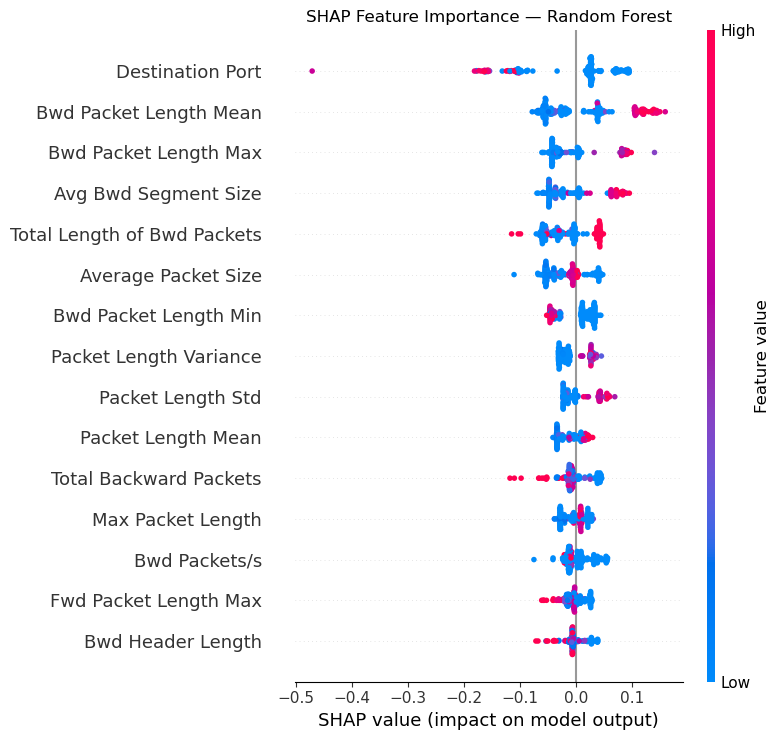

Saved to results/figures/shap_summary.png


In [ ]:
import shap
import numpy as np
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load model and data
rf_model      = joblib.load('../models/random_forest_model.pkl')
X_test        = np.load('../data/processed/X_test.npy')
feature_names = __import__('pandas').read_csv('../data/processed/feature_names.csv').iloc[:, 0].tolist()

# Use small sample for speed
sample_size = 200
idx         = np.random.choice(len(X_test), sample_size, replace=False)
X_sample    = X_test[idx]

print('Calculating SHAP values... (2-3 minutes)')
explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

print('Generating SHAP summary plot...')
plt.figure()
shap.summary_plot(
    shap_values[:,:,1],
    X_sample,
    feature_names=feature_names,
    show=False,
    max_display=15
)
plt.title('SHAP Feature Importance — Random Forest')
plt.tight_layout()
plt.savefig('../results/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to results/figures/shap_summary.png')

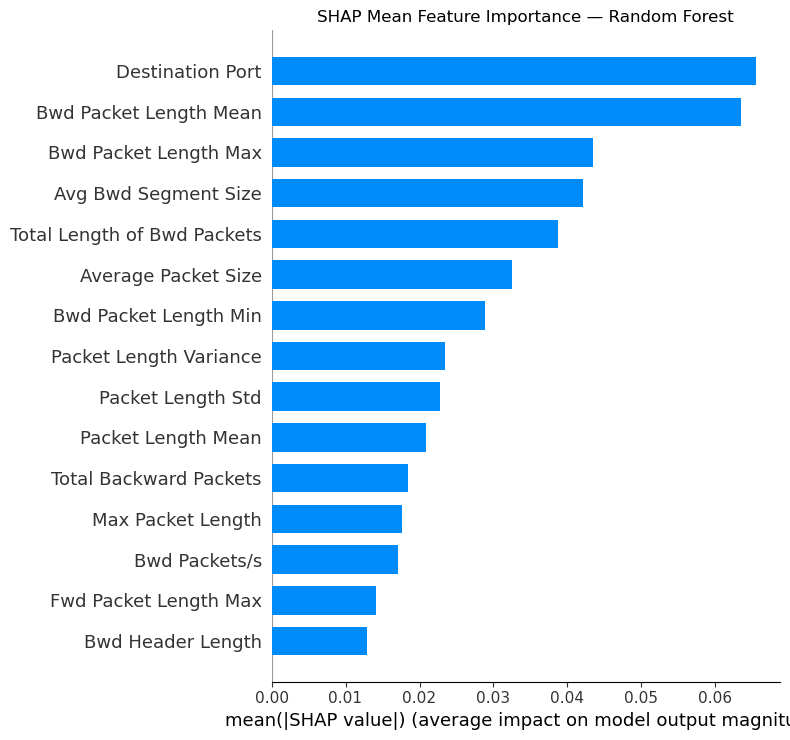

Saved to results/figures/shap_bar.png


In [ ]:
# SHAP bar plot — mean absolute importance
plt.figure()
shap.summary_plot(
    shap_values[:,:,1],
    X_sample,
    feature_names=feature_names,
    plot_type='bar',
    show=False,
    max_display=15
)
plt.title('SHAP Mean Feature Importance — Random Forest')
plt.tight_layout()
plt.savefig('../results/figures/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to results/figures/shap_bar.png')